# 🎯 Lorentzian KNN for Dynamic Risk Management

Uses **Lorentzian distance** (log-compressed L1) to find K historically similar trade setups
and derive adaptive Stop-Loss / Take-Profit levels from their outcome distributions.

**Why Lorentzian?** `Σ log(1 + |Δ|)` is outlier-robust — a 10× spike contributes only 3.4×
more distance, preventing market events from dominating neighbor selection.

## Role in the pipeline
```
_001 (Meta-labeling)   → Filters which trades to take
_002 (This notebook)   → For accepted trades, sets adaptive SL / TP
```

## Validation framework
```
For each test trade:
  1. Find K nearest historical setups (Lorentzian distance)
  2. Read their MAE / MFE distributions
  3. Set SL = sl_quantile(MAE),  TP = tp_quantile(MFE)
  4. Simulate: compare vs fixed-% stops and ATR stops
  5. Metric: Sharpe lift, max-drawdown reduction, profit factor
```

# 1. Setup

In [103]:
import sys, os, json, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']    = 100
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

backend_path = Path('../backend').resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

# 2. Load Data

Load `training_df` exported by `train_models_001.ipynb` (includes all features),
plus `stocks` panel for price-path MFE/MAE computation.

In [104]:
# ── Trade + feature data (from _001 export) ────────────────────────────────
training_df = pd.read_hdf('all_trades_with_features.h5', 'data')
training_df['entry_date'] = pd.to_datetime(training_df['entry_date'])
training_df['exit_date']  = pd.to_datetime(training_df['exit_date'])
training_df = training_df.sort_values('entry_date').reset_index(drop=True)

print(f"Trades loaded  : {len(training_df):,}")
print(f"Date range     : {training_df['entry_date'].min().date()} → {training_df['entry_date'].max().date()}")
print(f"Win rate       : {training_df['Y'].mean():.2%}")
print(f"Columns        : {list(training_df.columns)}")

# ── Stock close prices (for computing path excursions) ───────────────────────
with pd.HDFStore('stocks_data_latest.h5', mode='r') as _store:
    stocks = _store['stocks']
print(f"\nStocks panel   : {stocks.shape}  ({stocks.index.min().date()} → {stocks.index.max().date()})")

Trades loaded  : 14,128
Date range     : 2017-05-22 → 2026-04-17
Win rate       : 38.67%
Columns        : ['symbol', 'date', 'entry_date', 'exit_date', 'return', 'net_return', 'Y', 'rsi_window_5', 'rsi_window_14', 'mfi_21', 'obv', 'log_return', 'volume_threshold_ma_10', 'volume_threshold_ma_20', 'ema_10_distance', 'ema_20_distance', 'ema_50_distance', 'ema_200_distance', 'vwap_distance_highest', 'vwap_distance_lowest', 'efi_zscore_10', 'efi_zscore_20', 'rs_10', 'rs_20', 'mrs_10', 'mrs_20', 'msr_rank_10', 'msr_rank_20', 'zscore_10_log_return', 'zscore_20_log_return', 'yz_vol_10', 'yz_vol_20', 'dc_tmv', 'kf_distance', 'zscore_kf_10', 'zscore_kf_20', 'yz_vol_zscore_10', 'yz_vol_zscore_20', 'yz_vol_accel', 'mrs_overext_ratio', 'ema_near_far_ratio', 'rsi_rank_14', 'vol_spike', 'close_position', 'dist_20d_high', 'dist_60d_high', 'vnindex_above_ema50', 'vnindex_above_ema200', 'vnindex_ret_5d', 'vnindex_ret_20d', 'vnindex_vol_20d', 'vnindex_vol_zscore', 'vnindex_drawdown', 'rv_20', 'vol_pctile

# 3. Compute MFE / MAE

For each closed trade, walk the daily close path from `entry_date` to `exit_date`
and compute:
- **MFE** (Max Favorable Excursion) — best unrealized gain during hold
- **MAE** (Max Adverse Excursion) — worst unrealized loss during hold

These are the labels the Lorentzian KNN will learn to predict.

Computing MFE / MAE for all trades…
Dropped 4 trades (no price data) — 14,124 remain


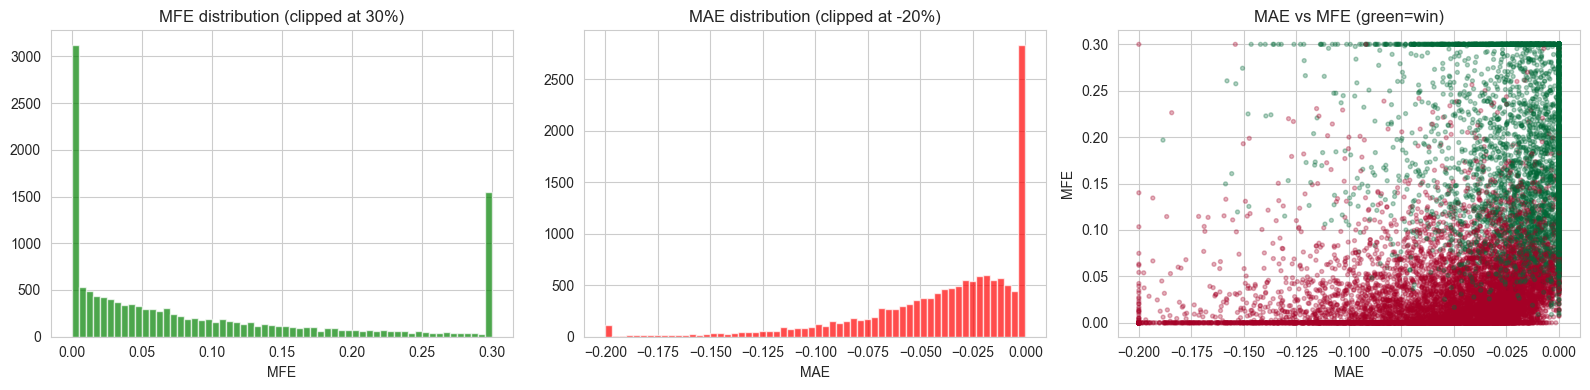

              mfe         mae    duration  net_return
count  14124.0000  14124.0000  14124.0000  14124.0000
mean       0.1255     -0.0401     22.1345      0.0279
std        0.2299      0.0417     21.7350      0.1848
min        0.0000     -0.3935      1.0000     -0.3965
25%        0.0088     -0.0584      9.0000     -0.0548
50%        0.0546     -0.0294     16.0000     -0.0178
75%        0.1473     -0.0084     29.0000      0.0504
max        7.5627      0.0000    831.0000      4.9207


In [105]:
def compute_mfe_mae(df: pd.DataFrame, close: pd.DataFrame) -> pd.DataFrame:
    """
    Compute daily-granularity MFE/MAE for each trade.
    Path approximation: assumes worst/best point occurs at a daily close.
    """
    mfe_list, mae_list, dur_list = [], [], []

    for _, t in df.iterrows():
        sym, t0, t1 = t['symbol'], t['entry_date'], t['exit_date']
        if sym not in close.columns:
            mfe_list.append(np.nan); mae_list.append(np.nan); dur_list.append(np.nan)
            continue
        path = close[sym].loc[t0:t1].dropna()
        if len(path) < 2:
            mfe_list.append(np.nan); mae_list.append(np.nan); dur_list.append(np.nan)
            continue
        r = path / path.iloc[0] - 1
        mfe_list.append(float(r.max()))
        mae_list.append(float(r.min()))
        dur_list.append(len(path) - 1)

    out = df.copy()
    out['mfe']      = mfe_list
    out['mae']      = mae_list
    out['duration'] = dur_list
    return out

print("Computing MFE / MAE for all trades…")
training_df = compute_mfe_mae(training_df, stocks['close'])
n_before = len(training_df)
training_df = training_df.dropna(subset=['mfe', 'mae']).reset_index(drop=True)
print(f"Dropped {n_before - len(training_df)} trades (no price data) — {len(training_df):,} remain")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(training_df['mfe'].clip(0, 0.30), bins=60, color='green', alpha=0.7)
axes[0].set_title('MFE distribution (clipped at 30%)'); axes[0].set_xlabel('MFE')
axes[1].hist(training_df['mae'].clip(-0.20, 0), bins=60, color='red',   alpha=0.7)
axes[1].set_title('MAE distribution (clipped at -20%)'); axes[1].set_xlabel('MAE')
axes[2].scatter(training_df['mae'].clip(-0.20, 0), training_df['mfe'].clip(0, 0.30),
                c=training_df['Y'], cmap='RdYlGn', alpha=0.3, s=8)
axes[2].set_xlabel('MAE'); axes[2].set_ylabel('MFE')
axes[2].set_title('MAE vs MFE (green=win)')
plt.tight_layout(); plt.show()

print(training_df[['mfe', 'mae', 'duration', 'net_return']].describe().round(4))

# 4. Lorentzian KNN — Implementation

Distance metric: $d(x,y) = \\sum_i \\ln(1 + |x_i - y_i|)$

Key properties vs Euclidean:
- A 10× feature spike → 3.4× distance (not 10×) — outlier robust
- Log compression = "curved geometry" across market regimes

In [106]:
from sklearn.preprocessing import StandardScaler

class LorentzianKNN:
    """
    Instance-based risk estimator using Lorentzian distance.
    fit()  stores training features + MFE / MAE outcomes.
    predict_risk() finds K nearest historical setups and returns
    adaptive SL / TP from the empirical MAE / MFE distributions.
    """

    def __init__(self, n_neighbors: int = 20, chronological_step: int = 1):
        self.k    = n_neighbors
        self.step = chronological_step   # temporal-diversity filter (TradingView style)

    @staticmethod
    def _lorentzian(x: np.ndarray, Y: np.ndarray) -> np.ndarray:
        """Lorentzian distance from point x to each row of Y. O(n*d)."""
        return np.sum(np.log1p(np.abs(Y - x)), axis=1)

    def fit(self, X: np.ndarray, mfe: np.ndarray,
            mae: np.ndarray, net_return: np.ndarray) -> 'LorentzianKNN':
        self.scaler_    = StandardScaler().fit(X)
        self.X_train_   = self.scaler_.transform(X).astype(np.float64)
        self.mfe_       = np.asarray(mfe,        dtype=np.float64)
        self.mae_       = np.asarray(mae,        dtype=np.float64)
        self.return_    = np.asarray(net_return, dtype=np.float64)
        return self

    def _neighbor_idx(self, x_scaled: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        dist = self._lorentzian(x_scaled, self.X_train_)
        # Chronological step filter — keep every step-th candidate only
        if self.step > 1:
            mask = np.zeros(len(dist), dtype=bool)
            mask[::self.step] = True
            dist = np.where(mask, dist, np.inf)
        k = min(self.k, int((dist < np.inf).sum()))
        idx = np.argpartition(dist, k - 1)[:k]
        idx = idx[dist[idx] < np.inf]
        return idx, dist[idx]

    def predict_risk(self, x: np.ndarray,
                     sl_quantile: float = 0.20,
                     tp_quantile: float = 0.70) -> dict | None:
        """
        Returns adaptive SL/TP for a single query vector x.
        sl_quantile: 20th pct of MAE → SL triggers on 20% of similar past setups
        tp_quantile: 70th pct of MFE → TP fires when move is strong enough
        """
        x_s = self.scaler_.transform(x.reshape(1, -1))[0]
        idx, dist = self._neighbor_idx(x_s)
        if len(idx) < 3:
            return None

        w = 1.0 / (dist + 1e-9);  w /= w.sum()
        mae_n = self.mae_[idx];    mfe_n = self.mfe_[idx]
        ret_n = self.return_[idx]

        return {
            'stop_loss_pct':       float(np.quantile(mae_n, sl_quantile)),
            'take_profit_pct':     float(np.quantile(mfe_n, tp_quantile)),
            'neighbor_avg_return': float((w * ret_n).sum()),
            'neighbor_win_rate':   float((ret_n > 0).mean()),
            'neighbor_mfe_mean':   float(mfe_n.mean()),
            'neighbor_mae_mean':   float(mae_n.mean()),
            'neighbor_count':      int(len(idx)),
        }

    def predict_risk_batch(self, X: np.ndarray,
                           sl_quantile: float = 0.20,
                           tp_quantile: float = 0.70,
                           chunk: int = 200) -> pd.DataFrame:
        """
        Vectorised batch prediction.
        Processes `chunk` rows at a time to keep memory ≤ ~200 MB.
        """
        X_s   = self.scaler_.transform(X).astype(np.float64)
        n, d  = X_s.shape
        n_ref = self.X_train_.shape[0]

        sl_arr  = np.full(n, np.nan)
        tp_arr  = np.full(n, np.nan)
        wr_arr  = np.full(n, np.nan)
        ret_arr = np.full(n, np.nan)
        cnt_arr = np.zeros(n, dtype=int)

        for start in range(0, n, chunk):
            end   = min(start + chunk, n)
            Xc    = X_s[start:end]                  # (c, d)
            # (c, n_ref) Lorentzian distance matrix
            dist  = np.sum(np.log1p(np.abs(Xc[:, None, :] - self.X_train_[None, :, :])), axis=2)

            if self.step > 1:
                mask = np.zeros(n_ref, dtype=bool); mask[::self.step] = True
                dist = np.where(mask[None, :], dist, np.inf)

            k = min(self.k, n_ref)
            for j in range(end - start):
                row = dist[j]
                valid = row < np.inf
                if valid.sum() < 3:
                    continue
                idx = np.argpartition(row, k - 1)[:k]
                idx = idx[row[idx] < np.inf]
                w   = 1.0 / (row[idx] + 1e-9);  w /= w.sum()

                mae_n = self.mae_[idx];   mfe_n = self.mfe_[idx]
                sl_arr[start + j]  = np.quantile(mae_n, sl_quantile)
                tp_arr[start + j]  = np.quantile(mfe_n, tp_quantile)
                wr_arr[start + j]  = (self.return_[idx] > 0).mean()
                ret_arr[start + j] = (w * self.return_[idx]).sum()
                cnt_arr[start + j] = len(idx)

        return pd.DataFrame({
            'stop_loss_pct':       sl_arr,
            'take_profit_pct':     tp_arr,
            'neighbor_win_rate':   wr_arr,
            'neighbor_avg_return': ret_arr,
            'neighbor_count':      cnt_arr,
        })

print("LorentzianKNN defined.")

LorentzianKNN defined.


# 5. Feature Selection for KNN

Lorentzian KNN works best with **bounded, stationary** features.
Curse of dimensionality becomes severe beyond 10-15 features.

In [107]:
# Candidate features for Lorentzian KNN — must be bounded / stationary
# Grouped by category; cross-sectional features are CRITICAL for VN market
_candidates = [
    # ── Oscillators (0–100 bounded) ───────────────────────────────────────
    'rsi_window_5', 'rsi_window_14', 'mfi_21',

    # ── Cross-sectional ranks (0–1, stationary by construction) ──────────
    'msr_rank_10', 'msr_rank_20',
    'rsi_rank_14',
    'dollar_vol_pctile',

    # ── Volatility (annualised, roughly bounded 0–2) ───────────────────────
    'yz_vol_10', 'yz_vol_20',
    'rv_20',
    'vol_pctile',        # 0–1 empirical CDF
    'atr_pct',           # ATR / close, ~0–0.10 for VN

    # ── Position / range (0–1 or log-ratio near 0) ────────────────────────
    'close_position',
    'range_pos_60',      # 0=at 60d low, 1=at 60d high
    'dist_from_high_60', # log-ratio ≤ 0

    # ── Trend (log-return, roughly bounded ±0.5) ─────────────────────────
    'trend_20',
    'sma_alignment',     # 0–1 fraction of SMAs price is above

    # ── Volume (z-score / percentile) ─────────────────────────────────────
    'vol_zscore',
    'vol_spike',

    # ── Cross-sectional vs VNINDEX (CRITICAL for VN market) ───────────────
    'rs_vnindex',        # 20d return diff vs VNINDEX
    'corr_vnindex',      # 60d rolling correlation (-1 to 1)
    'beta_60d',          # 60d rolling beta

    # ── VNINDEX market regime ──────────────────────────────────────────────
    'vnindex_above_ema50', 'vnindex_above_ema200',
    'vnindex_ret_20d', 'vnindex_drawdown',
    'vnindex_vol_zscore',
]

KNN_FEATURES = [c for c in _candidates if c in training_df.columns]
print(f'KNN features ({len(KNN_FEATURES)}): {KNN_FEATURES}')

_nan = training_df[KNN_FEATURES].isna().sum()
print(f'\nNaN counts:\n{_nan[_nan > 0]}' if _nan.any() else '\nNo NaN in KNN features.')

for col in KNN_FEATURES:
    if training_df[col].isna().any():
        training_df[col] = training_df[col].fillna(training_df[col].median())


KNN features (27): ['rsi_window_5', 'rsi_window_14', 'mfi_21', 'msr_rank_10', 'msr_rank_20', 'rsi_rank_14', 'dollar_vol_pctile', 'yz_vol_10', 'yz_vol_20', 'rv_20', 'vol_pctile', 'atr_pct', 'close_position', 'range_pos_60', 'dist_from_high_60', 'trend_20', 'sma_alignment', 'vol_zscore', 'vol_spike', 'rs_vnindex', 'corr_vnindex', 'beta_60d', 'vnindex_above_ema50', 'vnindex_above_ema200', 'vnindex_ret_20d', 'vnindex_drawdown', 'vnindex_vol_zscore']

No NaN in KNN features.


# 6. Train / Test Split

Use the same chronological boundary as `_001` to ensure consistent evaluation.

In [108]:
TRAIN_END_DATE = '2022-06-30'
EMBARGO_DAYS   = 10

train_mask = training_df['entry_date'] <= pd.Timestamp(TRAIN_END_DATE)
embargo_end = pd.Timestamp(TRAIN_END_DATE) + pd.Timedelta(days=EMBARGO_DAYS)
test_mask  = training_df['entry_date'] > embargo_end

train_df = training_df[train_mask].copy().reset_index(drop=True)
test_df  = training_df[test_mask].copy().reset_index(drop=True)

print(f"Train: {len(train_df):,} trades  ({train_df['entry_date'].min().date()} → {train_df['entry_date'].max().date()})")
print(f"Test : {len(test_df):,}  trades  ({test_df['entry_date'].min().date()} → {test_df['entry_date'].max().date()})")
print(f"\nTrain MFE:  mean={train_df['mfe'].mean():.3%}  median={train_df['mfe'].median():.3%}")
print(f"Train MAE:  mean={train_df['mae'].mean():.3%}  median={train_df['mae'].median():.3%}")

Train: 7,780 trades  (2017-05-22 → 2022-06-30)
Test : 6,321  trades  (2022-07-12 → 2026-04-16)

Train MFE:  mean=14.147%  median=5.846%
Train MAE:  mean=-3.986%  median=-2.973%


# 7. Fit Lorentzian KNN on Training Set

In [109]:
# Default hyperparameters — tuned in section 10
K                = 25
SL_QUANTILE      = 0.20   # 20th pct of MAE → stop that activates on 20% of similar setups
TP_QUANTILE      = 0.70   # 70th pct of MFE → take-profit at a realistically reachable level
CHRONOLOGICAL_STEP = 1    # 1 = no filter; >1 = TradingView temporal diversity

X_train = train_df[KNN_FEATURES].values
X_test  = test_df[KNN_FEATURES].values

knn = LorentzianKNN(n_neighbors=K, chronological_step=CHRONOLOGICAL_STEP)
knn.fit(X_train, train_df['mfe'].values, train_df['mae'].values, train_df['net_return'].values)
print(f"KNN fitted on {len(X_train):,} training samples × {len(KNN_FEATURES)} features")
print(f"Hyperparams: K={K}, sl_q={SL_QUANTILE}, tp_q={TP_QUANTILE}, step={CHRONOLOGICAL_STEP}")

KNN fitted on 7,780 training samples × 27 features
Hyperparams: K=25, sl_q=0.2, tp_q=0.7, step=1


# 8. Predict Adaptive SL / TP for Test Set

Running batch Lorentzian KNN prediction on test set…
Test predictions: 6,321 / 6,321 valid

Predicted SL (stop_loss_pct):
count    6321.0000
mean       -0.0613
std         0.0264
min        -0.2073
25%        -0.0715
50%        -0.0557
75%        -0.0431
max        -0.0118
Name: stop_loss_pct, dtype: float64

Predicted TP (take_profit_pct):
count    6321.0000
mean        0.1408
std         0.0827
min         0.0109
25%         0.0754
50%         0.1245
75%         0.1866
max         0.5628
Name: take_profit_pct, dtype: float64


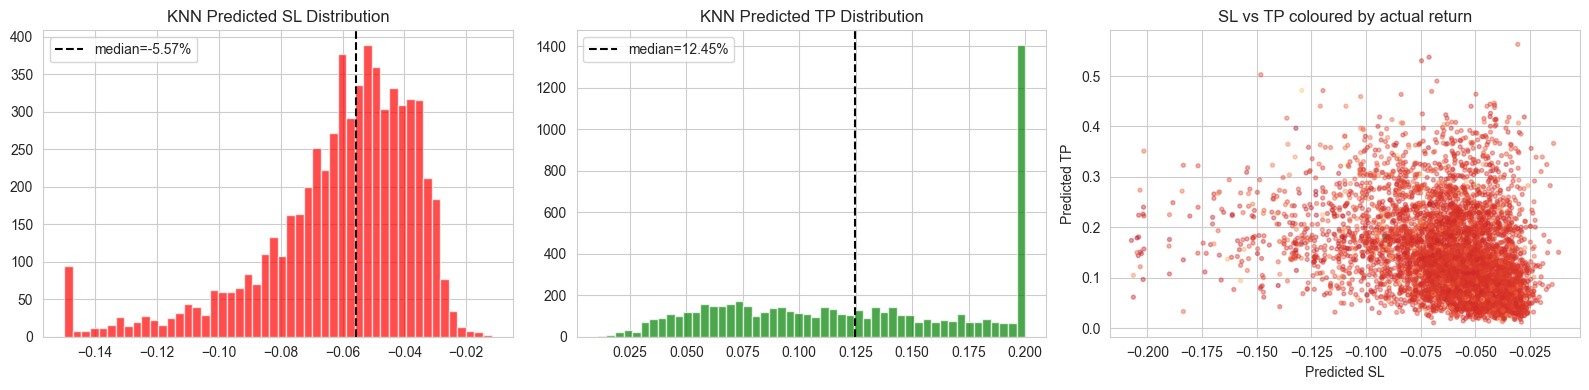

In [110]:
print("Running batch Lorentzian KNN prediction on test set…")
risk_preds = knn.predict_risk_batch(X_test, SL_QUANTILE, TP_QUANTILE)
test_df = pd.concat([test_df.reset_index(drop=True), risk_preds], axis=1)

print(f"Test predictions: {risk_preds['stop_loss_pct'].notna().sum():,} / {len(test_df):,} valid")
print(f"\nPredicted SL (stop_loss_pct):")
print(test_df['stop_loss_pct'].describe().round(4))
print(f"\nPredicted TP (take_profit_pct):")
print(test_df['take_profit_pct'].describe().round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(test_df['stop_loss_pct'].dropna().clip(-0.15, 0), bins=50, color='red', alpha=0.7)
axes[0].axvline(test_df['stop_loss_pct'].median(), color='black', linestyle='--', label=f"median={test_df['stop_loss_pct'].median():.2%}")
axes[0].set_title('KNN Predicted SL Distribution'); axes[0].legend()

axes[1].hist(test_df['take_profit_pct'].dropna().clip(0, 0.20), bins=50, color='green', alpha=0.7)
axes[1].axvline(test_df['take_profit_pct'].median(), color='black', linestyle='--', label=f"median={test_df['take_profit_pct'].median():.2%}")
axes[1].set_title('KNN Predicted TP Distribution'); axes[1].legend()

axes[2].scatter(test_df['stop_loss_pct'], test_df['take_profit_pct'],
                c=test_df['net_return'], cmap='RdYlGn', alpha=0.4, s=8)
axes[2].set_xlabel('Predicted SL'); axes[2].set_ylabel('Predicted TP')
axes[2].set_title('SL vs TP coloured by actual return')
plt.tight_layout(); plt.show()

# 9. Simulate SL/TP Strategies

For each test trade we simulate 4 scenarios using daily MAE/MFE as proxy for the price path:

| Scenario | Stop Loss | Take Profit |
|---|---|---|
| **Baseline** | none (strategy's natural exit) | none |
| **Fixed -3% SL** | -3.0% | none |
| **ATR SL** | -2 × yz_vol_10 | none |
| **KNN adaptive** | KNN predicted SL | KNN predicted TP |

Path approximation (daily bars):
- If `MAE ≤ SL` → stopped at SL (assumed first)
- Elif `MFE ≥ TP` → closed at TP
- Else → natural exit

In [95]:
ROUND_TRIP_COST = 0.003   # extra cost on early exit (matches _001)

def simulate_exits(df: pd.DataFrame,
                   sl_col: str | None,
                   tp_col: str | None) -> pd.Series:
    """
    Simulate trade returns given per-trade SL/TP columns (or fixed scalars).
    Uses MAE/MFE as daily-bar path approximation.
    """
    results = np.empty(len(df))
    for i, (_, row) in enumerate(df.iterrows()):
        mae = row['mae'];    mfe = row['mfe']
        nat = row['net_return']
        sl  = row[sl_col]  if sl_col  and sl_col  in row.index else None
        tp  = row[tp_col]  if tp_col  and tp_col  in row.index else None

        if sl is not None and not np.isnan(sl) and mae <= sl:
            results[i] = sl - ROUND_TRIP_COST    # stopped out
        elif tp is not None and not np.isnan(tp) and mfe >= tp:
            results[i] = tp - ROUND_TRIP_COST    # take profit hit
        else:
            results[i] = nat                     # natural exit
    return pd.Series(results, index=df.index)

# ── Fixed -3% SL ─────────────────────────────────────────────────────────────
test_df['sl_fixed'] = -0.03
test_df['tp_none']  = np.nan

# ── ATR-approximated SL: 2 × yz_vol_10 (annualised → daily: /√252) ──────────
if 'yz_vol_10' in test_df.columns:
    test_df['sl_atr'] = -(2 * test_df['yz_vol_10'] / np.sqrt(252)).clip(0.01, 0.08)
else:
    test_df['sl_atr'] = -0.03

scenarios = {
    'Baseline (no SL/TP)': simulate_exits(test_df, None, None),
    'Fixed -3% SL':         simulate_exits(test_df, 'sl_fixed', 'tp_none'),
    'ATR SL (2×yz_vol)':    simulate_exits(test_df, 'sl_atr',   'tp_none'),
    'KNN adaptive SL+TP':   simulate_exits(test_df, 'stop_loss_pct', 'take_profit_pct'),
}
print("Scenarios simulated.")

Scenarios simulated.


# 10. Risk Management Metrics Comparison

=== Risk Management Strategy Comparison (Test Set) ===
                     n_trades  win_rate  mean_return  sharpe  max_drawdown  \
Baseline (no SL/TP)    6121.0    0.3895       0.0146  1.5273          -1.0   
Fixed -3% SL           6121.0    0.3266       0.0224  2.6835          -1.0   
ATR SL (2×yz_vol)      6121.0    0.3596       0.0209  2.3771          -1.0   
KNN adaptive SL+TP     6121.0    0.3937       0.0057  1.1015          -1.0   

                     profit_factor  avg_win  avg_loss  
Baseline (no SL/TP)         1.4180   0.1271   -0.0572  
Fixed -3% SL                2.1512   0.1282   -0.0289  
ATR SL (2×yz_vol)           1.8337   0.1281   -0.0392  
KNN adaptive SL+TP          1.2022   0.0857   -0.0463  


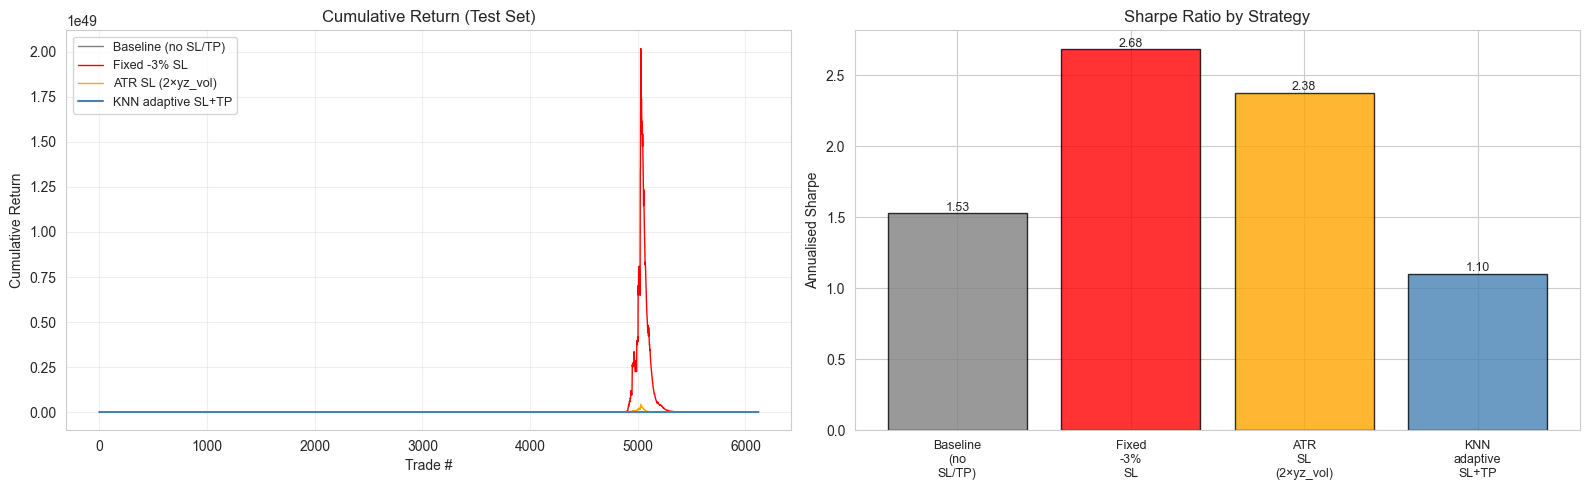

In [96]:
def strategy_metrics(returns: pd.Series) -> dict:
    r = returns.dropna()
    n = len(r)
    if n == 0:
        return {}
    cum  = (1 + r).cumprod()
    dd   = (cum / cum.cummax() - 1)
    win  = r[r > 0];  loss = r[r <= 0]
    return {
        'n_trades':      n,
        'win_rate':      float((r > 0).mean()),
        'mean_return':   float(r.mean()),
        'sharpe':        float(r.mean() / (r.std() + 1e-9) * np.sqrt(252)),
        'max_drawdown':  float(dd.min()),
        'profit_factor': float(abs(win.sum() / (loss.sum() + 1e-9))),
        'avg_win':       float(win.mean()) if len(win) else 0,
        'avg_loss':      float(loss.mean()) if len(loss) else 0,
        'sl_hit_rate':   float((r <= r.quantile(0.05)).mean()),  # proxy
    }

rows = {name: strategy_metrics(ret) for name, ret in scenarios.items()}
comp = pd.DataFrame(rows).T
display_cols = ['n_trades', 'win_rate', 'mean_return', 'sharpe',
                'max_drawdown', 'profit_factor', 'avg_win', 'avg_loss']
print("=== Risk Management Strategy Comparison (Test Set) ===")
print(comp[display_cols].round(4))

# ── Equity curves ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['gray', 'red', 'orange', 'steelblue']
for (name, ret), col in zip(scenarios.items(), colors):
    cum = (1 + ret).cumprod()
    axes[0].plot(cum.values, label=name, color=col, linewidth=1.5 if 'KNN' in name else 1)
axes[0].set_title('Cumulative Return (Test Set)')
axes[0].set_xlabel('Trade #'); axes[0].set_ylabel('Cumulative Return')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Bar chart: Sharpe comparison
names   = list(comp.index)
sharpes = comp['sharpe'].values
bar_colors = ['gray', 'red', 'orange', 'steelblue']
bars = axes[1].bar(range(len(names)), sharpes, color=bar_colors, alpha=0.8, edgecolor='black')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
axes[1].set_title('Sharpe Ratio by Strategy')
axes[1].set_ylabel('Annualised Sharpe')
axes[1].axhline(0, color='black', linewidth=0.5)
for bar, v in zip(bars, sharpes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# 11. KNN Prediction Calibration

Are the predicted SL/TP levels actually meaningful?
Check: does predicted `neighbor_win_rate` correlate with actual trade outcomes?

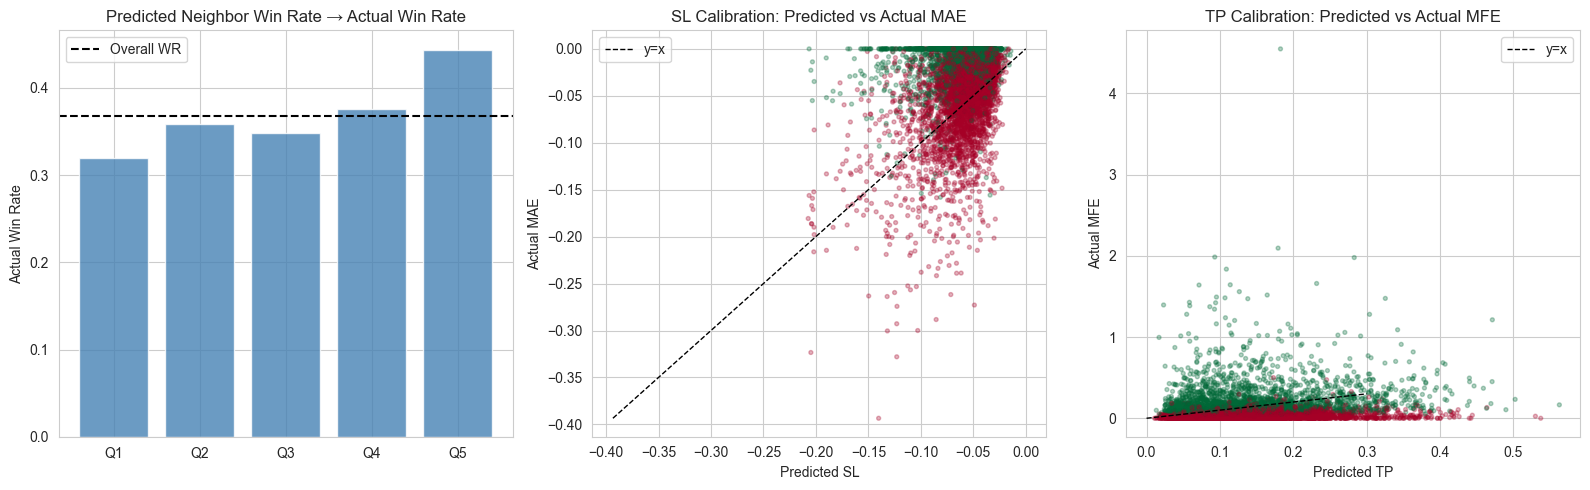

SL correlation (predicted SL vs actual MAE): 0.317
TP correlation (predicted TP vs actual MFE): 0.138
SL hit rate (MAE <= predicted SL):          25.49%
TP hit rate (MFE >= predicted TP):          26.14%


In [97]:
valid = test_df.dropna(subset=['stop_loss_pct', 'take_profit_pct', 'neighbor_win_rate'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Predicted neighbor_win_rate vs actual win rate in bins
bins = pd.qcut(valid['neighbor_win_rate'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
bin_wr = valid.groupby(bins, observed=True)['Y'].mean()
axes[0].bar(range(5), bin_wr.values, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(bin_wr.index)
axes[0].axhline(valid['Y'].mean(), color='black', linestyle='--', label='Overall WR')
axes[0].set_title('Predicted Neighbor Win Rate → Actual Win Rate')
axes[0].set_ylabel('Actual Win Rate'); axes[0].legend()

# 2. Predicted SL vs actual MAE
axes[1].scatter(valid['stop_loss_pct'], valid['mae'],
                alpha=0.3, s=8, c=valid['Y'], cmap='RdYlGn')
m = min(valid['stop_loss_pct'].min(), valid['mae'].min())
M = max(valid['stop_loss_pct'].max(), valid['mae'].max())
axes[1].plot([m, M], [m, M], 'k--', linewidth=1, label='y=x')
axes[1].set_xlabel('Predicted SL'); axes[1].set_ylabel('Actual MAE')
axes[1].set_title('SL Calibration: Predicted vs Actual MAE')
axes[1].legend()

# 3. Predicted TP vs actual MFE
axes[2].scatter(valid['take_profit_pct'], valid['mfe'],
                alpha=0.3, s=8, c=valid['Y'], cmap='RdYlGn')
axes[2].plot([0, 0.3], [0, 0.3], 'k--', linewidth=1, label='y=x')
axes[2].set_xlabel('Predicted TP'); axes[2].set_ylabel('Actual MFE')
axes[2].set_title('TP Calibration: Predicted vs Actual MFE')
axes[2].legend()

plt.tight_layout(); plt.show()

# Calibration stats
corr_sl = valid['stop_loss_pct'].corr(valid['mae'])
corr_tp = valid['take_profit_pct'].corr(valid['mfe'])
print(f"SL correlation (predicted SL vs actual MAE): {corr_sl:.3f}")
print(f"TP correlation (predicted TP vs actual MFE): {corr_tp:.3f}")
print(f"SL hit rate (MAE <= predicted SL):          {(valid['mae'] <= valid['stop_loss_pct']).mean():.2%}")
print(f"TP hit rate (MFE >= predicted TP):          {(valid['mfe'] >= valid['take_profit_pct']).mean():.2%}")

# 12. Hyperparameter Tuning via Optuna

Tune `K`, `sl_quantile`, `tp_quantile` to maximise Sharpe on the **training set**
(using time-ordered holdout to avoid look-ahead).

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Split training data: 70% fit, 30% evaluation (chronological)
_cut = int(len(train_df) * 0.70)
X_fit   = train_df.iloc[:_cut][KNN_FEATURES].values
X_eval  = train_df.iloc[_cut:][KNN_FEATURES].values
mfe_fit = train_df.iloc[:_cut]['mfe'].values
mae_fit = train_df.iloc[:_cut]['mae'].values
ret_fit = train_df.iloc[:_cut]['net_return'].values
eval_df = train_df.iloc[_cut:].copy().reset_index(drop=True)

def _sharpe(ret):
    r = pd.Series(ret).dropna()
    return float(r.mean() / (r.std() + 1e-9) * np.sqrt(252)) if len(r) > 5 else -99

def objective(trial):
    k      = trial.suggest_int('n_neighbors',  5, 50)
    sl_q   = trial.suggest_float('sl_quantile', 0.10, 0.40)
    tp_q   = trial.suggest_float('tp_quantile', 0.50, 0.90)
    step   = trial.suggest_int('chronological_step', 1, 5)

    _knn = LorentzianKNN(n_neighbors=k, chronological_step=step)
    _knn.fit(X_fit, mfe_fit, mae_fit, ret_fit)

    preds = _knn.predict_risk_batch(X_eval, sl_q, tp_q)
    _eval = eval_df.copy()
    _eval['stop_loss_pct']   = preds['stop_loss_pct'].values
    _eval['take_profit_pct'] = preds['take_profit_pct'].values

    sim = simulate_exits(_eval, 'stop_loss_pct', 'take_profit_pct')
    return _sharpe(sim)

study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"\nBest Sharpe (train holdout): {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/500 [00:00<?, ?it/s]


Best Sharpe (train holdout): 4.0581
Best params:
  n_neighbors: 45
  sl_quantile: 0.3936148006706789
  tp_quantile: 0.8928868827432438
  chronological_step: 2


In [99]:
# Refit on FULL training set with tuned hyperparameters
best = study.best_params
knn_tuned = LorentzianKNN(
    n_neighbors=best['n_neighbors'],
    chronological_step=best['chronological_step'],
)
knn_tuned.fit(X_train,
              train_df['mfe'].values,
              train_df['mae'].values,
              train_df['net_return'].values)

SL_Q_BEST = best['sl_quantile']
TP_Q_BEST = best['tp_quantile']

print(f"Refitted KNN: K={best['n_neighbors']}, step={best['chronological_step']}")
print(f"SL quantile: {SL_Q_BEST:.2f}, TP quantile: {TP_Q_BEST:.2f}")

# Re-run test evaluation with tuned params
risk_preds_tuned = knn_tuned.predict_risk_batch(X_test, SL_Q_BEST, TP_Q_BEST)
test_df['sl_knn_tuned'] = risk_preds_tuned['stop_loss_pct'].values
test_df['tp_knn_tuned'] = risk_preds_tuned['take_profit_pct'].values

scenarios_tuned = {**scenarios,
    'KNN tuned SL+TP': simulate_exits(test_df, 'sl_knn_tuned', 'tp_knn_tuned')}

rows_tuned = {name: strategy_metrics(ret) for name, ret in scenarios_tuned.items()}
print("\n=== Final Comparison (Test Set, Tuned KNN) ===")
print(pd.DataFrame(rows_tuned).T[display_cols].round(4))

Refitted KNN: K=40, step=3
SL quantile: 0.28, TP quantile: 0.90

=== Final Comparison (Test Set, Tuned KNN) ===
                     n_trades  win_rate  mean_return  sharpe  max_drawdown  \
Baseline (no SL/TP)    6121.0    0.3895       0.0146  1.5273          -1.0   
Fixed -3% SL           6121.0    0.3266       0.0224  2.6835          -1.0   
ATR SL (2×yz_vol)      6121.0    0.3596       0.0209  2.3771          -1.0   
KNN adaptive SL+TP     6121.0    0.3937       0.0057  1.1015          -1.0   
KNN tuned SL+TP        6121.0    0.3658       0.0134  2.0928          -1.0   

                     profit_factor  avg_win  avg_loss  
Baseline (no SL/TP)         1.4180   0.1271   -0.0572  
Fixed -3% SL                2.1512   0.1282   -0.0289  
ATR SL (2×yz_vol)           1.8337   0.1281   -0.0392  
KNN adaptive SL+TP          1.2022   0.0857   -0.0463  
KNN tuned SL+TP             1.5121   0.1083   -0.0413  


# 14. Walk-Forward Validation

Quarterly re-fit: at each quarter boundary, refit KNN on all past trades
and predict for the next quarter. No future leakage.

Running walk-forward validation (quarterly re-fit)…
  2022Q3  n=220  base Sharpe=-4.53  KNN Sharpe=-2.44  lift=+2.09
  2022Q4  n=447  base Sharpe=-0.51  KNN Sharpe=+1.84  lift=+2.36
  2023Q1  n=513  base Sharpe=+2.21  KNN Sharpe=+0.67  lift=-1.55
  2023Q2  n=354  base Sharpe=+8.55  KNN Sharpe=+10.36  lift=+1.80
  2023Q3  n=359  base Sharpe=+0.19  KNN Sharpe=+1.69  lift=+1.50
  2023Q4  n=543  base Sharpe=+0.89  KNN Sharpe=+1.94  lift=+1.05
  2024Q1  n=354  base Sharpe=+2.22  KNN Sharpe=+2.07  lift=-0.15
  2024Q2  n=354  base Sharpe=+5.24  KNN Sharpe=+6.40  lift=+1.17
  2024Q3  n=571  base Sharpe=-4.00  KNN Sharpe=-4.66  lift=-0.66
  2024Q4  n=435  base Sharpe=+0.53  KNN Sharpe=-0.35  lift=-0.88
  2025Q1  n=354  base Sharpe=+1.20  KNN Sharpe=+1.74  lift=+0.54
  2025Q2  n=373  base Sharpe=+10.27  KNN Sharpe=+12.41  lift=+2.13
  2025Q3  n=399  base Sharpe=-0.16  KNN Sharpe=+0.38  lift=+0.54
  2025Q4  n=498  base Sharpe=-3.01  KNN Sharpe=-2.94  lift=+0.06
  2026Q1  n=340  base Sharpe=-9.11 

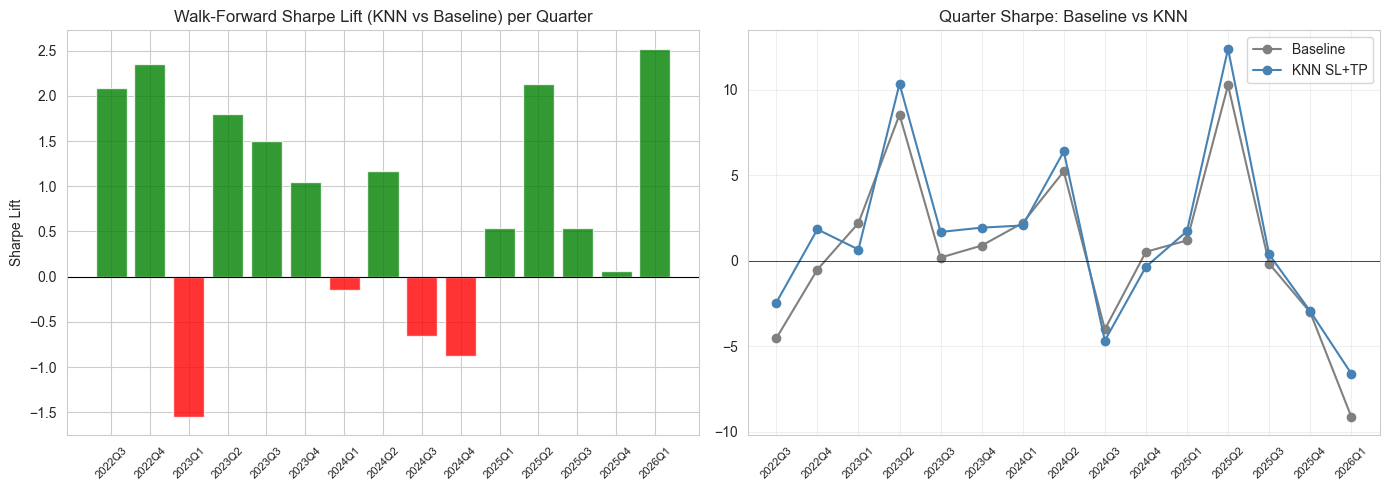

In [100]:
print("Running walk-forward validation (quarterly re-fit)…")

wf_results = []
quarters = pd.date_range(
    start=test_df['entry_date'].min().to_period('Q').to_timestamp(),
    end=test_df['entry_date'].max(),
    freq='QS'
)

for q_start in quarters:
    q_end = q_start + pd.offsets.QuarterEnd(0)
    q_mask = (test_df['entry_date'] >= q_start) & (test_df['entry_date'] <= q_end)
    q_df   = test_df[q_mask].copy().reset_index(drop=True)
    if len(q_df) < 10:
        continue

    # Training = all data BEFORE this quarter
    past_mask = training_df['entry_date'] < q_start
    past_df   = training_df[past_mask]
    if len(past_df) < 50:
        continue

    _X_past = past_df[KNN_FEATURES].values
    _knn = LorentzianKNN(n_neighbors=best['n_neighbors'],
                          chronological_step=best['chronological_step'])
    _knn.fit(_X_past, past_df['mfe'].values,
             past_df['mae'].values, past_df['net_return'].values)

    _preds = _knn.predict_risk_batch(q_df[KNN_FEATURES].values, SL_Q_BEST, TP_Q_BEST)
    q_df['sl_wf'] = _preds['stop_loss_pct'].values
    q_df['tp_wf'] = _preds['take_profit_pct'].values

    base_ret = q_df['net_return']
    knn_ret  = simulate_exits(q_df, 'sl_wf', 'tp_wf')

    wf_results.append({
        'quarter':     str(q_start.to_period('Q')),
        'n_trades':    len(q_df),
        'base_sharpe': _sharpe(base_ret),
        'knn_sharpe':  _sharpe(knn_ret),
        'base_mean':   float(base_ret.mean()),
        'knn_mean':    float(knn_ret.mean()),
        'sharpe_lift': _sharpe(knn_ret) - _sharpe(base_ret),
    })
    print(f"  {q_start.to_period('Q')}  n={len(q_df):3d}  "
          f"base Sharpe={_sharpe(base_ret):+.2f}  KNN Sharpe={_sharpe(knn_ret):+.2f}  "
          f"lift={_sharpe(knn_ret)-_sharpe(base_ret):+.2f}")

wf_df = pd.DataFrame(wf_results)
print(f"\nWalk-forward Sharpe lift: mean={wf_df['sharpe_lift'].mean():+.3f}  "
      f"median={wf_df['sharpe_lift'].median():+.3f}  "
      f"positive quarters={( wf_df['sharpe_lift']>0).mean():.0%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(wf_df))
axes[0].bar(x, wf_df['knn_sharpe'] - wf_df['base_sharpe'],
            color=['green' if v > 0 else 'red' for v in wf_df['sharpe_lift']], alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(wf_df['quarter'], rotation=45, fontsize=8)
axes[0].set_title('Walk-Forward Sharpe Lift (KNN vs Baseline) per Quarter')
axes[0].set_ylabel('Sharpe Lift')
axes[1].plot(wf_df['quarter'], wf_df['base_sharpe'], label='Baseline', color='gray', marker='o')
axes[1].plot(wf_df['quarter'], wf_df['knn_sharpe'],  label='KNN SL+TP', color='steelblue', marker='o')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xticklabels(wf_df['quarter'], rotation=45, fontsize=8)
axes[1].set_title('Quarter Sharpe: Baseline vs KNN')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 15. Save Artifacts

In [101]:
import joblib

artifacts_dir = '../models'
os.makedirs(artifacts_dir, exist_ok=True)
ts = datetime.now().strftime('%Y%m%d')

# Save tuned KNN model
joblib.dump(knn_tuned, f'{artifacts_dir}/lorentzian_knn_{ts}.joblib')

# Save metadata
meta = {
    'created':         datetime.now().isoformat(),
    'knn_features':    KNN_FEATURES,
    'n_neighbors':     best['n_neighbors'],
    'chron_step':      best['chronological_step'],
    'sl_quantile':     SL_Q_BEST,
    'tp_quantile':     TP_Q_BEST,
    'train_end_date':  TRAIN_END_DATE,
    'walk_fwd_sharpe_lift_mean':   float(wf_df['sharpe_lift'].mean()),
    'walk_fwd_positive_quarters':  float((wf_df['sharpe_lift'] > 0).mean()),
}
with open(f'{artifacts_dir}/lorentzian_knn_meta_{ts}.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f"Saved: {artifacts_dir}/lorentzian_knn_{ts}.joblib")
print(f"Saved: {artifacts_dir}/lorentzian_knn_meta_{ts}.json")
print("\nUsage in production:")
print("  knn = joblib.load('lorentzian_knn_YYYYMMDD.joblib')")
print("  risk = knn.predict_risk(current_features, sl_quantile=SL_Q, tp_quantile=TP_Q)")
print("  stop_price  = entry_price * (1 + risk['stop_loss_pct'])")
print("  target_price = entry_price * (1 + risk['take_profit_pct'])")

Saved: ../models/lorentzian_knn_20260502.joblib
Saved: ../models/lorentzian_knn_meta_20260502.json

Usage in production:
  knn = joblib.load('lorentzian_knn_YYYYMMDD.joblib')
  risk = knn.predict_risk(current_features, sl_quantile=SL_Q, tp_quantile=TP_Q)
  stop_price  = entry_price * (1 + risk['stop_loss_pct'])
  target_price = entry_price * (1 + risk['take_profit_pct'])


In [115]:
# ── Query SL/TP Levels for a Specific Symbol ─────────────────────────────────
QUERY_SYMBOL = 'DXG'   # ← change to any symbol

sym = test_df[test_df['symbol'] == QUERY_SYMBOL].copy()

if sym.empty:
    print(f'No test-set trades found for {QUERY_SYMBOL}')
else:
    sym = sym.sort_values('entry_date').reset_index(drop=True)

    # Derive entry_price from stocks close panel on entry_date
    close = stocks['close']
    sym['entry_price'] = sym.apply(
        lambda r: close[r['symbol']].get(r['entry_date'], np.nan)
        if r['symbol'] in close.columns else np.nan,
        axis=1,
    )

    sym['stop_price']   = sym['entry_price'] * (1 + sym['stop_loss_pct'])
    sym['target_price'] = sym['entry_price'] * (1 + sym['take_profit_pct'])
    sym['return'] = sym['return'] * 100
    out = sym[[
        'entry_date', 'exit_date', 'entry_price', 'return',
        'stop_price', 'target_price',
        'stop_loss_pct', 'take_profit_pct',
        'neighbor_win_rate', 'neighbor_count',
        'mfe', 'mae',
    ]].copy()
    pct_cols = ['stop_loss_pct', 'take_profit_pct', 'neighbor_win_rate', 'mfe', 'mae']
    out[pct_cols] = out[pct_cols].mul(100).round(2)
    out = out.rename(columns={
        'stop_loss_pct':  'sl_%',
        'take_profit_pct':'tp_%',
        'neighbor_win_rate': 'nbr_wr%',
        'mfe': 'mfe_%',
        'mae': 'mae_%',
    })

    print(f'{QUERY_SYMBOL}  —  {len(sym)} test-set trade(s)')
    display(out.tail(10))


DXG  —  34 test-set trade(s)


,entry_date,exit_date,entry_price,return,stop_price,target_price,sl_%,tp_%,nbr_wr%,neighbor_count,mfe_%,mae_%
24,2025-02-21,2025-03-31,12.95,4.247104,12.337652,13.379737,-4.73,3.32,16.0,25,11.89,0.00
25,2025-04-18,2025-08-22,12.18,65.435140,11.367090,14.164479,-6.67,16.29,52.0,25,79.80,-1.72
26,2025-08-07,2025-08-22,20.60,-2.184466,18.675445,22.440727,-9.34,8.94,20.0,25,6.31,-2.18
27,2025-08-28,2025-09-29,22.90,-4.585153,21.637035,26.865036,-5.52,17.31,52.0,25,5.68,-4.59
28,2025-10-14,2025-10-21,20.50,-2.439024,19.131841,22.992791,-6.67,12.16,36.0,25,10.24,-2.44
29,2025-11-18,2025-12-12,19.60,-14.540816,18.422684,21.445411,-6.01,9.42,28.0,25,0.00,-14.54
30,2025-12-23,2026-01-06,17.90,-6.983240,16.799151,19.725156,-6.15,10.20,32.0,25,1.40,-6.98
31,2026-02-04,2026-02-06,15.40,-7.142857,14.715480,17.828204,-4.44,15.77,48.0,25,0.00,-7.14
32,2026-02-11,2026-03-09,15.65,-15.974441,14.091410,16.697651,-9.96,6.69,24.0,25,2.24,-15.97
33,2026-03-18,2026-04-17,13.80,7.971014,13.363488,18.721256,-3.16,35.66,72.0,25,11.96,-5.43
